In [1]:
from experiments.dj.result_tables import VPostPriorResult
from experiments.dj.posterior_tables import VPostPriorConfig
from experiments.dj.trainer_tables import VPTrainerConfig
from experiments.dj.dataloader_tables import AltDataLoaderConfig
import datajoint as dj
from experiments.dj.schema import schema
from task_transfer.ml_lib.data_loading import build_dataloaders

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from experiments.dj.posterior_tables import SBVGPConfig
from experiments.dj.sysident_tables import SIConfig
from experiments.dj.result_tables import (
    SBVGPResult2,
    SIResult,
    FlowPriorResult,
    SBVGPAdaptedResult,
    FPSamplesConfig,
    FPSamples,
    MLPCondSamples2,
    AdaptPriorResult,
    LikelihoodResult,
)
from experiments.dj.dataloader_tables import DataLoaderConfig


from task_transfer.utils.insilico_stimuli import generate_gabors
from task_transfer.ml_lib.data_loading import build_dataloaders

from task_transfer.evaluation.evaluate_generative_model import (
    compute_logl,
    compute_haefner_logl_i_cond_x,
    visualize_conditional_features,
)

import torch
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from task_transfer.sampling_models.plotting import plot_cohen_task, plot_haefner_model


from task_transfer.utils.model_utils import build_haefner_model

import experiments.orientation_discrimination.haefner_model.configs as cfg

from pathlib import Path

import pickle


import numpy as np
from task_transfer.utils.math_utils import cos2_von_mises

torch.manual_seed(42)

seed = 42
torch.manual_seed(seed)

[2024-09-25 14:20:02,603][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2024-09-25 14:20:02,610][INFO]: Connected sshrinivasan@134.76.19.44:3306
/usr/local/lib/python3.8/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


In [2]:
vp_cols = [col for col in VPostPriorConfig.heading if col != "id"]
dl_cols = [col for col in AltDataLoaderConfig.heading if col != "id"]
trainer_cols = [col for col in VPTrainerConfig.heading if col != "id"]

results = VPostPriorConfig.proj(*vp_cols, **{"vp_id": "id"}) * VPTrainerConfig.proj(*trainer_cols, **{"trainer_id":"id"}) * AltDataLoaderConfig.proj(*dl_cols, **{"dl_id":"id"}) * VPostPriorResult

In [3]:
results

vp_id,trainer_id,dl_id,seed,post_dist_type,post_nonneg_transform,post_n_layers,post_nonlin,post_dropout_rate,post_init_std,post_kwargs,prior_fp_id to index into FlowPriorConfig,prior_trainer_id to index into FPTrainerConfig,likelihood_id to index into LikelihoodConfig,likelihood_trainer_id to index into LLTrainerConfig,orig_dl_id to index into DataLoaderConfig used to id the prior and likelihood,n_bound_samples,bound_type,lr,weight_decay,n_epochs,batch_size,early_stopping_threshold,early_stopping_patience,data_fname,train_prop,val_prop,"train_var_marginal_mean mean per trial, per sample, in nats",train_var_marginal_sem standard error of the mean,val_var_marginal_mean,val_var_marginal_sem,test_var_marginal_mean,test_var_marginal_sem,"train_marginal_obs_ll_mean mean per trial, per sample, in nats",train_marginal_obs_ll_sem standard error of the mean,val_marginal_obs_ll_mean,val_marginal_obs_ll_sem,test_marginal_obs_ll_mean,test_marginal_obs_ll_sem,"train_post_ll_mean mean per trial, per sample, in nats",train_post_ll_sem standard error of the mean,val_post_ll_mean,val_post_ll_sem,test_post_ll_mean,test_post_ll_sem,"train_prior_ll_mean mean per trial, per sample, in nats",train_prior_ll_sem standard error of the mean,val_prior_ll_mean,val_prior_ll_sem,test_prior_ll_mean,test_prior_ll_sem,tracker_output,eval_output,model trained variational model (with joint and posterior)
01e9d80e496d22d5fc4b1d5e4c0efdb3,06ee7c0da04334f4dbad37a27d7d2fb5,3d740ef65d4ec3d651cb862eb90143df,42,gamma,exp,4,relu,0.0,0.001,=BLOB=,89c1053a65023b042dc63f7f852bb5b0,c40a50ce9c77369770dddd5129836477,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,bb9bdd1ccd59e5a8c801d7f2d43e0317,100,iw,0.001,1e-05,100,128,10,10,/src/project/data/synthetic/haefner_2afc/haefner_model_4neuron_task2_dataset.pkl,0.7,0.2,-23.161558151245117,26.298738479614258,-33.45803451538086,31.834735870361328,-29.387657165527344,44.24879837036133,-48.08610153198242,88.90666961669922,-27.662734985351562,115.50831604003906,-12.151156425476074,100.80838775634766,-4.306342124938965,0.24633082747459412,-4.268877983093262,0.43999776244163513,-4.327520847320557,0.6242481470108032,-4.701415061950684,0.3025374114513397,-4.6410040855407715,0.5342189073562622,-4.695712566375732,0.7397690415382385,=BLOB=,=BLOB=,=BLOB=
01e9d80e496d22d5fc4b1d5e4c0efdb3,0cd3274d19c95ccff2db63c5644bae01,3d740ef65d4ec3d651cb862eb90143df,42,gamma,exp,4,relu,0.0,0.001,=BLOB=,89c1053a65023b042dc63f7f852bb5b0,c40a50ce9c77369770dddd5129836477,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,bb9bdd1ccd59e5a8c801d7f2d43e0317,100,elbo,0.001,1e-05,300,128,10,10,/src/project/data/synthetic/haefner_2afc/haefner_model_4neuron_task2_dataset.pkl,0.7,0.2,1352.235595703125,408.5346374511719,1340.5009765625,663.7172241210938,1253.314697265625,756.643798828125,-656.0164184570312,327.9098205566406,-633.1060180664062,528.89453125,-540.550048828125,520.9268798828125,-53.42240905761719,8.201157569885254,-52.5797119140625,14.551803588867188,-51.982872009277344,19.674169540405273,-31.209745407104492,5.265025615692139,-31.183094024658203,9.691041946411133,-29.542335510253906,11.911727905273438,=BLOB=,=BLOB=,=BLOB=
01e9d80e496d22d5fc4b1d5e4c0efdb3,13411240c1b15f4544e9bfb34462e23d,3d740ef65d4ec3d651cb862eb90143df,42,gamma,exp,4,relu,0.0,0.001,=BLOB=,89c1053a65023b042dc63f7f852bb5b0,c40a50ce9c77369770dddd5129836477,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,bb9bdd1ccd59e5a8c801d7f2d43e0317,1000,iw,0.001,1e-05,300,128,10,10,/src/project/data/synthetic/haefner_2afc/haefner_model_4neuron_task2_dataset.pkl,0.7,0.2,-32.15298843383789,20.36845588684082,-36.421875,34.805179595947266,-39.87627410888672,37.41229248046875,-46.269649505615234,95.78277587890625,-26.163103103637695,126.25935363769531,-19.267187118530273,133.15249633789062,-4.231546401977539,0.23553714156150818,-4.2003560066223145,0.42334312200546265,-4.263096332550049,0.6158022284507751,-4.653509140014648,0.2889823913574219,-4.606187343597412,0

In [19]:
best_val_results = results.fetch(
    download_path="/tmp",
    order_by="val_post_ll_mean DESC",
    as_dict=True,
    limit=1,
)[0]

In [20]:
model = torch.load(best_val_results["model"])

In [21]:
model

VariationalBound(
  (joint): Joint(
    (prior): FlowDistribution(
      (base_distribution): TrainableDistributionAdapter(
        distribution_class=<class 'torch.distributions.multivariate_normal.MultivariateNormal'>, loc=tensor([0., 0., 0., 0.], device='cuda:0'), covariance_matrix=Covariance()
        (covariance_matrix): Covariance()
      )
      (transform): SequentialTransform(
        (transforms): ModuleList(
          (0): InverseTransform(
            (transform): Softplus()
          )
          (1): IndependentAffine()
          (2): Tanh()
          (3): IndependentAffine()
          (4): Tanh()
          (5): IndependentAffine()
        )
      )
    )
    (conditional): IndependentNormal(
      (trainable_distribution): IndependentTrainableDistributionAdapter(
        distribution_class=<class 'torch.distributions.normal.Normal'>, event_dims=1
        (parameter_generator): LocScale(
          (core_nn): MLP(
            (core_module): Sequential(
              (linear

In [22]:
model.posterior

IndependentGamma(
  (trainable_distribution): IndependentTrainableDistributionAdapter(
    distribution_class=<class 'torch.distributions.gamma.Gamma'>, event_dims=1
    (parameter_generator): ConcRate(
      (core_nn): MLP(
        (core_module): Sequential(
          (linear_0): Linear(in_features=144, out_features=4, bias=True)
          (dropout_0): Dropout(p=0.0, inplace=False)
          (nonlin_0): ReLU()
        )
      )
      (conc_module): Linear(in_features=4, out_features=4, bias=True)
      (rate_module): Linear(in_features=4, out_features=4, bias=True)
    )
  )
)

In [23]:
best_val_results.keys()

dict_keys(['vp_id', 'trainer_id', 'dl_id', 'seed', 'post_dist_type', 'post_nonneg_transform', 'post_n_layers', 'post_nonlin', 'post_dropout_rate', 'post_init_std', 'post_kwargs', 'prior_fp_id', 'prior_trainer_id', 'likelihood_id', 'likelihood_trainer_id', 'orig_dl_id', 'n_bound_samples', 'bound_type', 'lr', 'weight_decay', 'n_epochs', 'batch_size', 'early_stopping_threshold', 'early_stopping_patience', 'data_fname', 'train_prop', 'val_prop', 'train_var_marginal_mean', 'train_var_marginal_sem', 'val_var_marginal_mean', 'val_var_marginal_sem', 'test_var_marginal_mean', 'test_var_marginal_sem', 'train_marginal_obs_ll_mean', 'train_marginal_obs_ll_sem', 'val_marginal_obs_ll_mean', 'val_marginal_obs_ll_sem', 'test_marginal_obs_ll_mean', 'test_marginal_obs_ll_sem', 'train_post_ll_mean', 'train_post_ll_sem', 'val_post_ll_mean', 'val_post_ll_sem', 'test_post_ll_mean', 'test_post_ll_sem', 'train_prior_ll_mean', 'train_prior_ll_sem', 'val_prior_ll_mean', 'val_prior_ll_sem', 'test_prior_ll_mean',

In [24]:
best_val_results["val_post_ll_mean"]/4/np.log(2)

-0.8514898020487591

In [25]:
best_val_results["test_post_ll_mean"] / 4 / np.log(2)

-0.8313019625425301

In [26]:
n_hist_samples = 500_000
prior_samples = model.joint.prior.sample((n_hist_samples,)).detach()

In [27]:
dataloader_config1 = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/haefner_model_4neuron_highdelta_task1_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
    "batch_size": 128,
}
train_loader1, val_loader1, test_loader1 = build_dataloaders(
    data_fname=dataloader_config1["data_fname"],
    train_prop=dataloader_config1["train_prop"],
    val_prop=dataloader_config1["val_prop"],
    batch_size=dataloader_config1["batch_size"],
)

dataloader_config2 = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/haefner_model_4neuron_highdelta_task2_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
    "batch_size": 128,
}
train_loader2, val_loader2, test_loader2 = build_dataloaders(
    data_fname=dataloader_config2["data_fname"],
    train_prop=dataloader_config2["train_prop"],
    val_prop=dataloader_config2["val_prop"],
    batch_size=dataloader_config2["batch_size"],
)

In [28]:
task1_params = cfg.haefner_model_4neuron_highdelta_task1
task2_params = cfg.haefner_model_4neuron_highdelta_task2

In [29]:
with open(task2_params["data_fname"], "rb") as f:
    task2_data_dict = pickle.load(f)

In [30]:
task2_x = task2_data_dict["x_samples"]
print(task2_x.shape)

torch.Size([10000, 4])


In [31]:
task1_data_model = build_haefner_model(
    p_c=task1_params["p_c"],
    c1_psi=task1_params["c1_psi"],
    c2_psi=task1_params["c2_psi"],
    kappa=task1_params["kappa"],
    g_phi=task1_params["g_phi"],
    delta=task1_params["delta"],
    lam=task1_params["lam"],
    x_phi=task1_params["x_phi"],
    obs_sigma=task1_params["obs_sigma"],
    obs_h=task1_params["obs_h"],
    obs_w=task1_params["obs_w"],
)

task2_data_model = build_haefner_model(
    p_c=task2_params["p_c"],
    c1_psi=task2_params["c1_psi"],
    c2_psi=task2_params["c2_psi"],
    kappa=task2_params["kappa"],
    g_phi=task2_params["g_phi"],
    delta=task2_params["delta"],
    lam=task2_params["lam"],
    x_phi=task2_params["x_phi"],
    obs_sigma=task2_params["obs_sigma"],
    obs_h=task2_params["obs_h"],
    obs_w=task2_params["obs_w"],
)

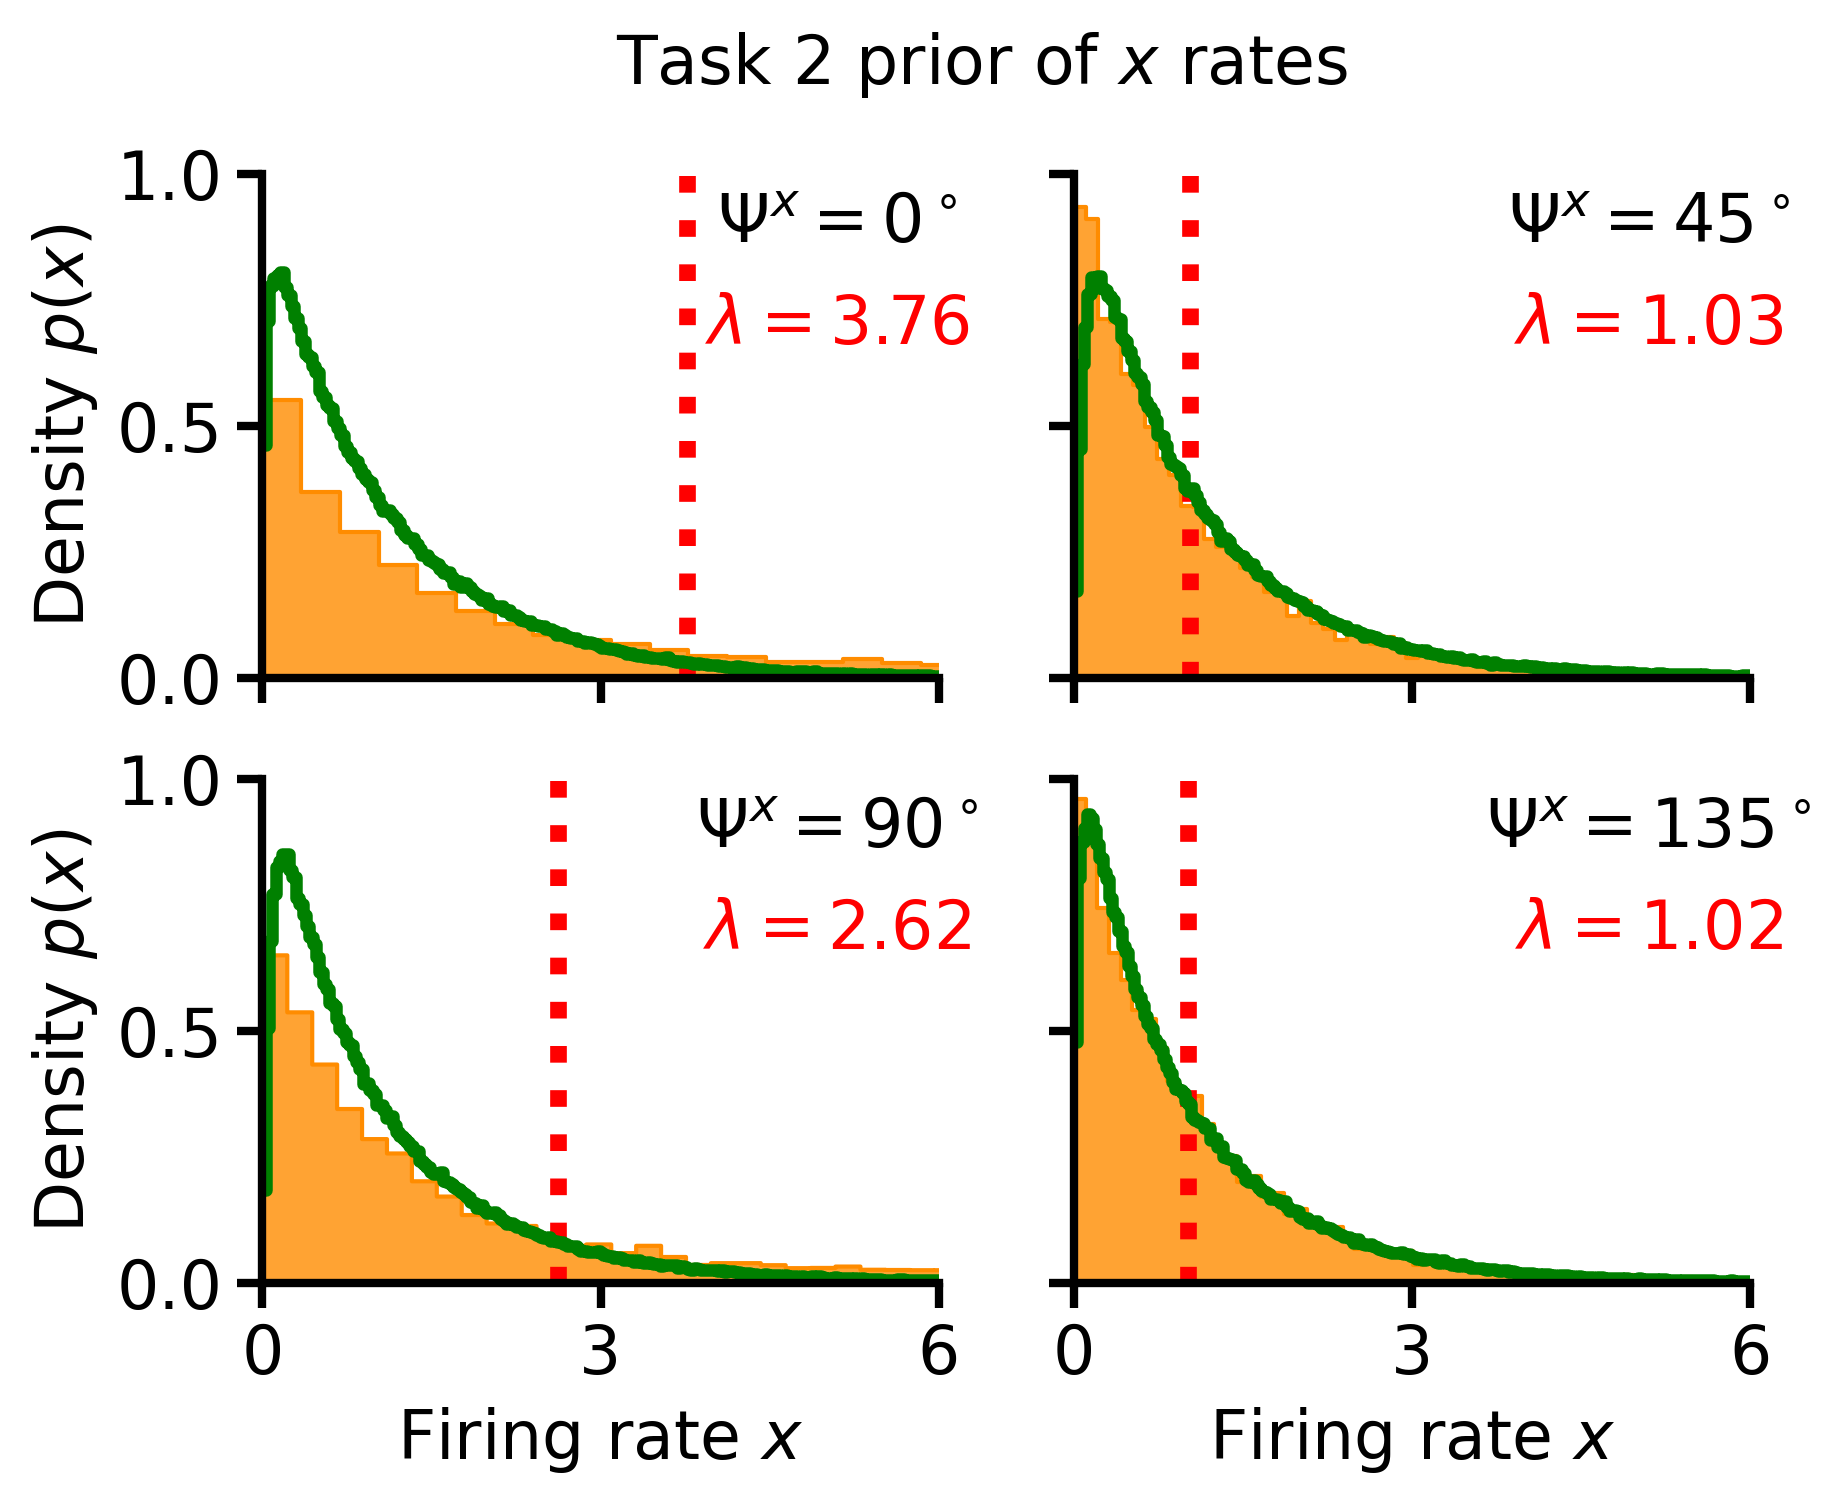

In [32]:
dpi = 300
fontsize = 16
linewidth = 4
tick_length = 6
tick_width = 2
prior_model_linewidth = 3
fig_xdist, axs_dist = plt.subplots(2, 2, dpi=dpi, sharex=True, sharey=True)
for idx, ax in enumerate(axs_dist.flatten()):
    sns.histplot(
        task2_x[:, idx],
        ax=ax,
        stat="density",
        element="step",
        # kde=True,
        color="darkorange",
        # label="No task",
        alpha=0.8,
        # linewidth=linewidth,
    )
    ax.text(
        0.85,
        0.9,
        f"$\\Psi^x=${int(np.rad2deg(task2_data_model.x_phi[idx]))}$^\circ$",
        horizontalalignment="center",
        verticalalignment="center",
        transform=ax.transAxes,
        fontsize=fontsize,
    )
    mean_samples = torch.mean(task2_x[:, idx])
    ax.axvline(mean_samples, color="red", linestyle="dotted", linewidth=linewidth)
    ax.text(
        0.85,
        0.7,
        f"$\\lambda=${mean_samples:.2f}",
        horizontalalignment="center",
        verticalalignment="center",
        transform=ax.transAxes,
        fontsize=fontsize,
        color="red",
        label="Mean",
    )
    sns.histplot(
        prior_samples[:, idx].detach().cpu(),
        ax=ax,
        stat="density",
        element="step",
        color="green",
        alpha=1,
        label="Model",
        fill=False,
        linewidth=prior_model_linewidth,
    )
    mean_hist_samples = torch.mean(prior_samples[:, idx]).item()
    # ax.axvline(
    #     mean_hist_samples, color="blue", linestyle="dotted", linewidth=linewidth
    # )
    # ax.text(
    #     0.7,
    #     0.5,
    #     f"$\\lambda=${mean_hist_samples:.2f}",
    #     horizontalalignment="center",
    #     verticalalignment="center",
    #     transform=ax.transAxes,
    #     fontsize=fontsize,
    #     color="blue",
    #     label="Mean",
    # )
    ax.set_xlim([0, 6])
    ax.set_ylim([0, 1])
    ax.set_xticks(np.arange(0, 7, step=3))
    ax.set_yticks([0, 0.5, 1])
    ax.tick_params(
        axis="both",
        which="both",
        labelsize=fontsize,
        length=tick_length,
        width=tick_width,
    )
    ax.set_ylabel("Density $p\\left(x\\right)$", fontsize=fontsize)
    ax.set_xlabel("Firing rate $x$", fontsize=fontsize)
    sns.despine(ax=ax)
    ax.spines[["left", "bottom"]].set_linewidth(tick_width)
    # ax.axis("equal")
fig_xdist.suptitle("Task 2 prior of $x$ rates", fontsize=fontsize)
xdist_figname2 = "4n_t2_prior.pdf"
# fig_xdist.savefig(xdist_figname2, bbox_inches="tight", transparent=True)